In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [3]:
df = pd.read_csv('mnist_test.csv')
df.head(1)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


In [5]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.443400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.isnull().sum

<bound method DataFrame.sum of       label    1x1    1x2    1x3    1x4    1x5    1x6    1x7    1x8    1x9  \
0     False  False  False  False  False  False  False  False  False  False   
1     False  False  False  False  False  False  False  False  False  False   
2     False  False  False  False  False  False  False  False  False  False   
3     False  False  False  False  False  False  False  False  False  False   
4     False  False  False  False  False  False  False  False  False  False   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9995  False  False  False  False  False  False  False  False  False  False   
9996  False  False  False  False  False  False  False  False  False  False   
9997  False  False  False  False  False  False  False  False  False  False   
9998  False  False  False  False  False  False  False  False  False  False   
9999  False  False  False  False  False  False  False  False  False  False   

      ...  28x19  28x20  28x21  

In [7]:
X = df.iloc[:, 1:]  # Drop labels
y = df.iloc[:, 0]  # Drop labels

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

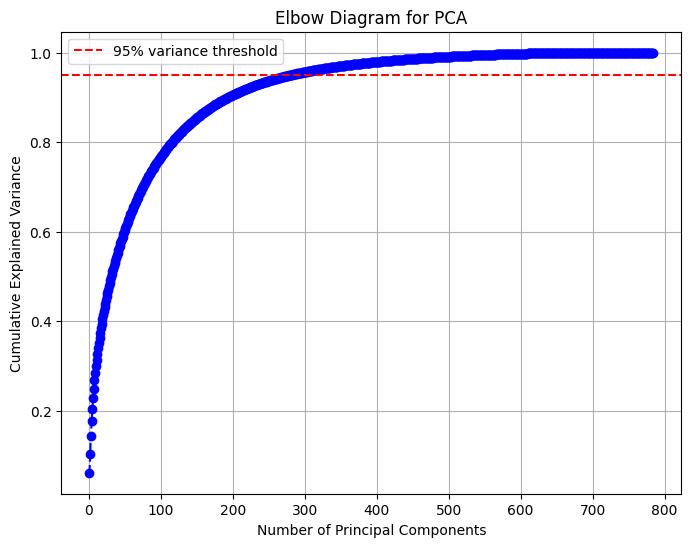

PC1: 0.0620 cumulative variance
PC2: 0.1044 cumulative variance
PC3: 0.1449 cumulative variance
PC4: 0.1772 cumulative variance
PC5: 0.2047 cumulative variance
PC6: 0.2288 cumulative variance
PC7: 0.2493 cumulative variance
PC8: 0.2681 cumulative variance
PC9: 0.2848 cumulative variance
PC10: 0.3000 cumulative variance
PC11: 0.3147 cumulative variance
PC12: 0.3278 cumulative variance
PC13: 0.3403 cumulative variance
PC14: 0.3523 cumulative variance
PC15: 0.3637 cumulative variance
PC16: 0.3747 cumulative variance
PC17: 0.3850 cumulative variance
PC18: 0.3949 cumulative variance
PC19: 0.4044 cumulative variance
PC20: 0.4135 cumulative variance
PC21: 0.4224 cumulative variance
PC22: 0.4311 cumulative variance
PC23: 0.4396 cumulative variance
PC24: 0.4478 cumulative variance
PC25: 0.4556 cumulative variance
PC26: 0.4633 cumulative variance
PC27: 0.4709 cumulative variance
PC28: 0.4782 cumulative variance
PC29: 0.4853 cumulative variance
PC30: 0.4922 cumulative variance
PC31: 0.4988 cumula

In [10]:
# Apply PCA without specifying n_components to consider all components
pca = PCA()
pca.fit(X_scaled)

# Get explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the elbow diagram
plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.title('Elbow Diagram for PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.legend(loc='best')
plt.show()

# Explained variance ratio output
for i, var in enumerate(explained_variance, 1):
    print(f"PC{i}: {var:.4f} cumulative variance")

# Conclusion based on 95% variance threshold
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print(f"\nNumber of components needed to explain 95% of the variance: {n_components_95}")

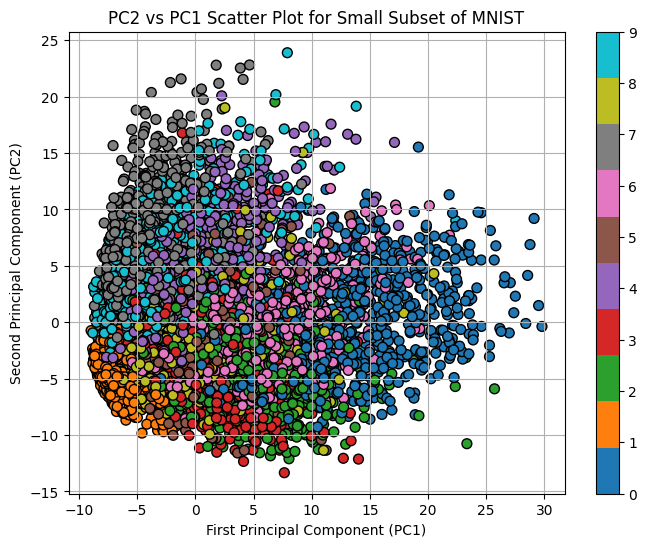

Explained variance ratio of PC1: 0.0620
Explained variance ratio of PC2: 0.0424


In [11]:
# Apply PCA with two components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PC2 vs PC1
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', edgecolor='k', s=50)
plt.colorbar(scatter)
plt.title('PC2 vs PC1 Scatter Plot for Small Subset of MNIST')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.grid(True)
plt.show()

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio of PC1: {explained_variance_ratio[0]:.4f}")
print(f"Explained variance ratio of PC2: {explained_variance_ratio[1]:.4f}")

In [12]:
from sklearn.manifold import TSNE

e:\repos\DS203\venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


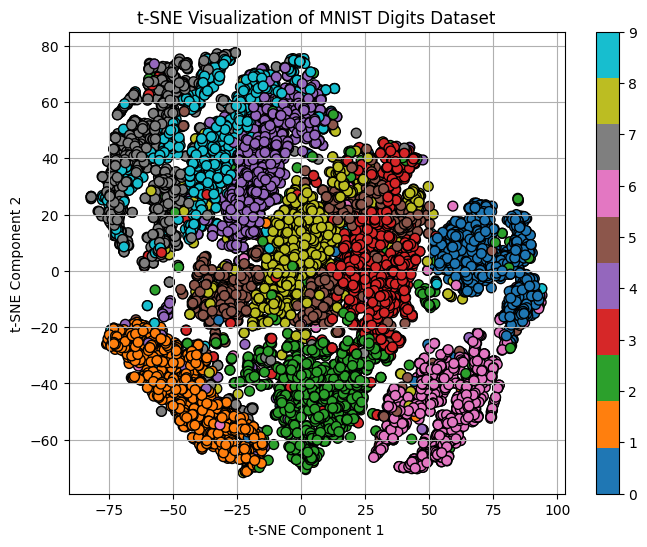

In [13]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Plot the t-SNE results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', edgecolor='k', s=50)
plt.colorbar(scatter)
plt.title('t-SNE Visualization of MNIST Digits Dataset')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()